In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 9 — QuickSort e QuickSelect

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. Exercício 9 **→ você está aqui**
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

In [4]:
# Estruturas definidas na seção de outro exercício do notebook
# único, reimportadas aqui para este notebook rodar sozinho.
from src.linked_list import SinglyLinkedList
from src.searching import generate_array

---
# Exercício 9 — QuickSort e QuickSelect

## Enunciado
`quicksort(arr, short)` contando cópias e comparações, com insertion sort para
subvetores ≤ `short`, em 4 padrões × ≥3 valores de `short`; `quickselect`
comparado com ordenar tudo; e uma variante em `SinglyLinkedList` com partição em
três listas, discutindo por que o custo muda sem acesso por índice.

## Implementação — `src/sorting.py`

**Decisão de projeto 5 — a escolha do pivô é um parâmetro, não uma constante.**
Sem isso o exercício não conseguiria mostrar o que pede: com `last`, uma entrada
**já ordenada** faz o quicksort virar Θ(n²); com `median3`, a mesma entrada vira
o melhor caso. O impacto do padrão de entrada não é propriedade do quicksort, é
propriedade do par (quicksort, estratégia de pivô).

**Decisão de projeto 6 — recursão só na metade menor; a maior vira laço.**
Limita a pilha a `⌊log₂n⌋+1` quadros mesmo com partição péssima. É otimização de
**memória** que não altera o **tempo** — e separar as duas coisas é parte da análise.

In [5]:
from src.sorting import (PIVOT_STRATEGIES, SHORT_VALUES, bench_linked_quicksort,
                         bench_pivot_strategies, bench_quickselect_vs_sort, bench_quicksort,
                         partition_three_way, quickselect, quicksort, quicksort_depth,
                         quicksort_linked)

entrada = generate_array(500, "aleatorio")
for estrategia in PIVOT_STRATEGIES:
    for corte in SHORT_VALUES:
        assert quicksort(entrada, corte, pivot=estrategia) == sorted(entrada)
for k in (0, 250, 499):
    assert quickselect(entrada, k) == sorted(entrada)[k]
assert quicksort_linked(SinglyLinkedList(entrada)).to_list() == sorted(entrada)
print("quicksort (3 pivôs × 3 shorts), quickselect e a variante em lista: todos corretos")

menores, iguais, maiores = partition_three_way(SinglyLinkedList([5, 2, 8, 5, 1, 9, 5]), 5)
print(f"\npartição em três: menores={menores.to_list()} iguais={iguais.to_list()} "
      f"maiores={maiores.to_list()}")

quicksort (3 pivôs × 3 shorts), quickselect e a variante em lista: todos corretos

partição em três: menores=[2, 1] iguais=[5, 5, 5] maiores=[8, 9]


In [6]:
quick = pd.DataFrame(bench_quicksort())
mostrar(quick[quick["n"] == 16_000],
        ["padrao", "short", "comparisons", "copies", "comparisons/n_log2n",
         "calls", "calls/n", "profundidade_maxima"],
        "QUICKSORT: 4 PADRÕES × 3 VALORES DE short (n = 16.000)")

QUICKSORT: 4 PADRÕES × 3 VALORES DE short (n = 16.000)


,padrao,short,comparisons,copies,comparisons/n_log2n,calls,calls/n,profundidade_maxima
24,ordenado,0,216204,49146,0.9676,8192,0.5120,14
25,ordenado,8,189963,36092,0.8501,2048,0.1280,12
26,ordenado,32,159497,33020,0.7138,512,0.0320,10
27,reverso,0,410889,718416,1.8388,8772,0.5483,13
28,reverso,8,409659,723664,1.8333,4413,0.2758,12
29,reverso,32,499835,778384,2.2369,1277,0.0798,10
30,quase_ordenado,0,289833,56244,1.2971,8432,0.5270,14
31,quase_ordenado,8,265840,43100,1.1897,2470,0.1544,12
32,quase_ordenado,32,235112,38962,1.0522,865,0.0541,10
33,aleatorio,0,246131,352425,1.1015,9145,0.5716,10


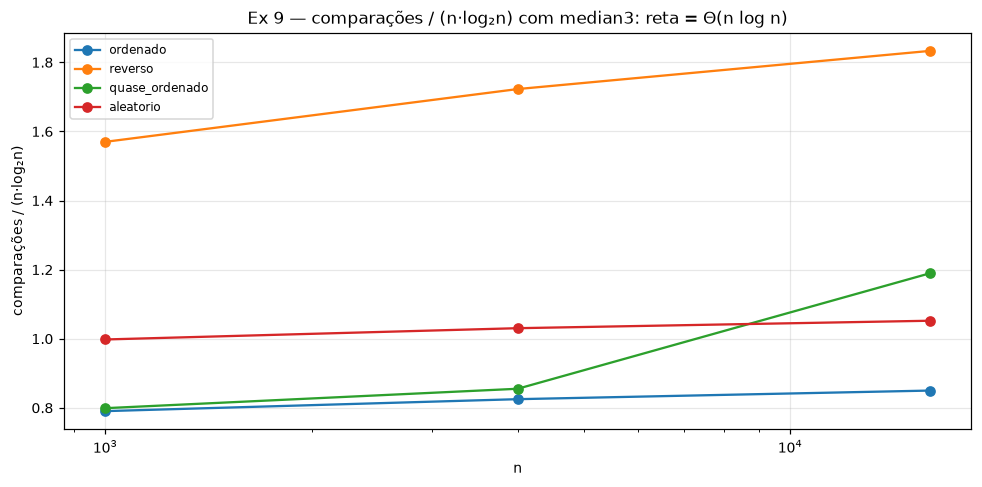


Com median3, TODOS os padrões ficam na mesma faixa de n·log₂n — é isso que
torna o quicksort útil na prática, e é o contraste com a tabela do ex 2,
onde a mesma coluna explodia.

O efeito do `short` é de CONSTANTE, não de classe:
  short= 0 →  8,635 chamadas recursivas em média
  short= 8 →  2,917 chamadas recursivas em média
  short=32 →    863 chamadas recursivas em média
  (short=32 usa 10.0× menos chamadas que short=0)


In [7]:
grafico_razao(quick[quick["short"] == 8], "n", "comparisons/n_log2n", "padrao",
              "Ex 9 — comparações / (n·log₂n) com median3: reta = Θ(n log n)",
              "ex09_quicksort.png", "comparações / (n·log₂n)")

de_16k = quick[quick["n"] == 16_000]
chamadas = de_16k.groupby("short")["calls"].mean()
veredito(
    "Com median3, TODOS os padrões ficam na mesma faixa de n·log₂n — é isso que\n"
    "torna o quicksort útil na prática, e é o contraste com a tabela do ex 2,\n"
    "onde a mesma coluna explodia.\n\n"
    "O efeito do `short` é de CONSTANTE, não de classe:\n"
    + "\n".join(f"  short={int(s):>2} → {int(c):>6,} chamadas recursivas em média"
                for s, c in chamadas.items())
    + f"\n  (short=32 usa {chamadas[0]/chamadas[32]:.1f}× menos chamadas que short=0)"
)

In [8]:
pivos = pd.DataFrame(bench_pivot_strategies([4_000]))
mostrar(pivos, ["padrao", "pivo", "comparisons", "comparacoes/n_log2n", "comparacoes/n2",
                "profundidade_maxima", "log2n_mais_1"],
        "O IMPACTO DO PADRÃO DE ENTRADA DEPENDE DA ESTRATÉGIA DE PIVÔ (n = 4.000)")

O IMPACTO DO PADRÃO DE ENTRADA DEPENDE DA ESTRATÉGIA DE PIVÔ (n = 4.000)


,padrao,pivo,comparisons,comparacoes/n_log2n,comparacoes/n2,profundidade_maxima,log2n_mais_1
0,ordenado,last,7998000,167.1015,0.4999,2,12
1,ordenado,median3,46058,0.9623,0.0029,12,12
2,ordenado,random,52306,1.0928,0.0033,9,12
3,aleatorio,last,55550,1.1606,0.0035,9,12
4,aleatorio,median3,52188,1.0904,0.0033,9,12
5,aleatorio,random,53263,1.1128,0.0033,8,12


In [9]:
ordenado_last = pivos[(pivos["padrao"] == "ordenado") & (pivos["pivo"] == "last")].iloc[0]
ordenado_med3 = pivos[(pivos["padrao"] == "ordenado") & (pivos["pivo"] == "median3")].iloc[0]
veredito(
    "MESMA ENTRADA ORDENADA, mesmo código, só o pivô diferente:\n"
    f"  pivot='last'    → {int(ordenado_last['comparisons']):>9,} comparações  "
    f"(razão/n² = {ordenado_last['comparacoes/n2']:.4f})  ⇒ Θ(n²), o PIOR caso\n"
    f"  pivot='median3' → {int(ordenado_med3['comparisons']):>9,} comparações  "
    f"(razão/n·log₂n = {ordenado_med3['comparacoes/n_log2n']:.4f})  ⇒ Θ(n log n), o MELHOR\n"
    f"  {ordenado_last['comparisons']/ordenado_med3['comparisons']:.0f}× de diferença.\n\n"
    "E a coluna da profundidade separa duas coisas que se confundem:\n"
    f"  no caso Θ(n²), a pilha usou {int(ordenado_last['profundidade_maxima'])} quadros, "
    f"não {int(ordenado_last['n']):,}.\n"
    "  Tempo ruim e memória boa COEXISTEM: a recursão desce só na metade menor."
)


MESMA ENTRADA ORDENADA, mesmo código, só o pivô diferente:
  pivot='last'    → 7,998,000 comparações  (razão/n² = 0.4999)  ⇒ Θ(n²), o PIOR caso
  pivot='median3' →    46,058 comparações  (razão/n·log₂n = 0.9623)  ⇒ Θ(n log n), o MELHOR
  174× de diferença.

E a coluna da profundidade separa duas coisas que se confundem:
  no caso Θ(n²), a pilha usou 2 quadros, não 4,000.
  Tempo ruim e memória boa COEXISTEM: a recursão desce só na metade menor.


QUICKSELECT × ORDENAR TUDO (mediana)


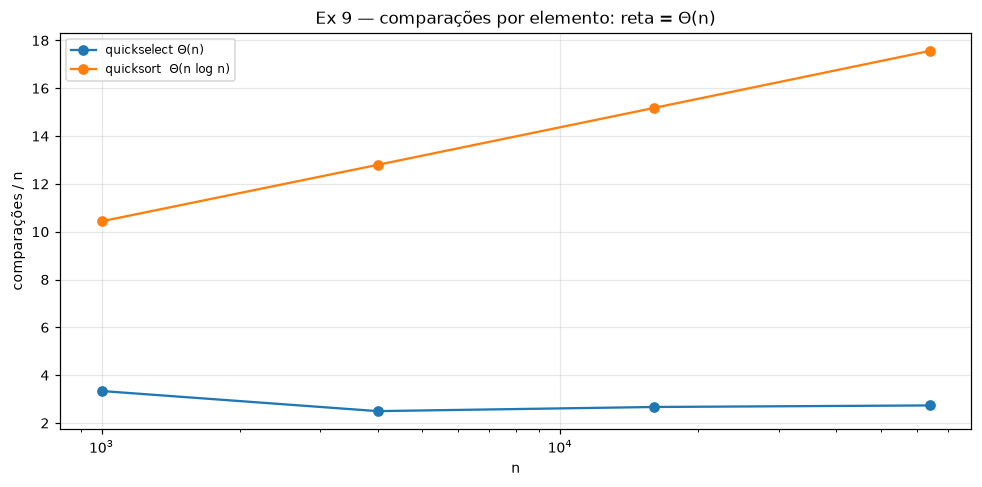


select/n fica preso entre 2.50 e 3.34 enquanto n cresce 64×  ⇒ Θ(n)
sort/n cresce de 10.44 a 17.57, acompanhando log₂n  ⇒ Θ(n log n)
ganho: 3.1× → 6.4× — cresce com n.


In [10]:
selecao = pd.DataFrame(bench_quickselect_vs_sort(positions=(0.5,)))
mostrar(selecao, ["n", "goal_index", "select_comparacoes", "select/n", "sort_comparacoes",
                  "sort/n", "sort/n_log2n", "razao_sort_sobre_select"],
        "QUICKSELECT × ORDENAR TUDO (mediana)")

curvas_sel = pd.concat([
    selecao.assign(versao="quickselect Θ(n)", razao=lambda d: d["select/n"]),
    selecao.assign(versao="quicksort  Θ(n log n)", razao=lambda d: d["sort/n"]),
])
grafico_razao(curvas_sel, "n", "razao", "versao",
              "Ex 9 — comparações por elemento: reta = Θ(n)",
              "ex09_quickselect.png", "comparações / n")
veredito(
    f"select/n fica preso entre {selecao['select/n'].min():.2f} e {selecao['select/n'].max():.2f} "
    "enquanto n cresce 64×  ⇒ Θ(n)\n"
    f"sort/n cresce de {selecao['sort/n'].min():.2f} a {selecao['sort/n'].max():.2f}, "
    "acompanhando log₂n  ⇒ Θ(n log n)\n"
    f"ganho: {selecao['razao_sort_sobre_select'].min():.1f}× → "
    f"{selecao['razao_sort_sobre_select'].max():.1f}× — cresce com n."
)

### Variante em lista encadeada — o preço de não ter índice

In [11]:
lista_quick = pd.DataFrame(bench_linked_quicksort([2_000]))
linha = lista_quick.iloc[0]
print(f"{'':<26}{'array':>12}{'lista encadeada':>18}")
for rotulo, coluna_a, coluna_l in [("comparações", "array_comparacoes", "lista_comparacoes"),
                                   ("cópias", "array_copias", "lista_copias"),
                                   ("saltos de ponteiro", "array_saltos", "lista_saltos"),
                                   ("chamadas recursivas", "array_chamadas", "lista_chamadas")]:
    print(f"  {rotulo:<24}{int(linha[coluna_a]):>12,}{int(linha[coluna_l]):>18,}")
print(f"\n  razão de comparações: {linha['razao_comparacoes']:.2f}×   "
      f"cópias: {linha['razao_copias']:.2f}×   tempo: {linha['razao_tempo']:.2f}×")

# partição de três vias resolve chaves iguais em Θ(n)
iguais_counters = Counters()
quicksort_linked(SinglyLinkedList([7] * 2_000), iguais_counters)
print(f"\n2.000 chaves IDÊNTICAS na variante em lista: {iguais_counters.calls} chamadas "
      f"(todos caem em `iguais`, uma partição só)")

                                 array   lista encadeada
  comparações                   23,694            39,027
  cópias                        35,505            51,012
  saltos de ponteiro                 0            24,179
  chamadas recursivas            1,151             2,655

  razão de comparações: 1.65×   cópias: 1.44×   tempo: 14.07×

2.000 chaves IDÊNTICAS na variante em lista: 3 chamadas (todos caem em `iguais`, uma partição só)


**Por que o custo muda sem acesso por índice:**

1. **Não há partição no lugar.** O array troca dois elementos por índice em O(1);
   a lista teria de religar ponteiros conhecendo o antecessor. A saída é construir
   listas novas — Θ(n) de memória por nível contra Θ(1) do array.
2. **Não há pivô aleatório barato.** Sortear um índice e ir até ele custa O(n)
   numa lista. O pivô aqui é o **primeiro** elemento, que é O(1) — e o preço é
   que entrada ordenada vira o pior caso, Θ(n²), exatamente como `pivot="last"`.
3. **Em compensação, sai estabilidade de graça**, e a partição em três vias
   resolve chaves iguais em Θ(n) — cenário em que a partição de Lomuto do array
   degeneraria.

A variante em lista faz **1,65× mais comparações** porque a partição de três vias
usa até 2 comparações por elemento contra 1 da de Lomuto. É o preço de tratar
iguais em tempo linear.